##Milestone -02
##Project name :-AirFly Insights: Data Visualization and Analysis of Airline Operations

**Milestone 2:** Visual Exploration and Delay Trends



Week 3: Univariate and Bivariate Visual Analysis

•Top airlines, routes, and busiest months

•Flight distribution by day, time, and airport

•Plot bar charts, histograms, boxplots, and line plots




**Week 4:** Delay Analysis – Airline and Weather

•Compare delay causes by airline

•Explore carrier delays, weather delays, NAS delays

•Visualize delays by time of day and airport
Deliverables:

•Set of visualizations (minimum 8)
•Observations on peak delays and top delay-prone carriers

##Visual Exploration and Delay Trends

##Univariate and Bivariate Visual Analysis

**Setup & Data Loading**

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_flights.csv")

df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,MONTH,DAY_OF_WEEK,HOUR,ROUTE
0,2022-07-22,UNITED AIR LINES INC.,United Air Lines Inc.: UA,UA,19977.0,459.0,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,680.0,0.0,0.0,0.0,0.0,0.0,7,4,10.0,DEN-MSP
1,2019-07-31,SOUTHWEST AIRLINES CO.,Southwest Airlines Co.: WN,WN,19393.0,665.0,DAL,"Dallas, TX",OKC,"Oklahoma City, OK",...,181.0,141.0,0.0,0.0,0.0,0.0,7,2,12.0,DAL-OKC
2,2021-06-11,DELTA AIR LINES INC.,Delta Air Lines Inc.: DL,DL,19790.0,2820.0,ATL,"Atlanta, GA",BDL,"Hartford, CT",...,859.0,60.0,0.0,0.0,0.0,0.0,6,4,19.0,ATL-BDL
3,2021-08-05,SOUTHWEST AIRLINES CO.,Southwest Airlines Co.: WN,WN,19393.0,430.0,MDW,"Chicago, IL",BNA,"Nashville, TN",...,395.0,0.0,0.0,0.0,0.0,0.0,8,3,8.0,MDW-BNA
4,2022-05-01,SOUTHWEST AIRLINES CO.,Southwest Airlines Co.: WN,WN,19393.0,1011.0,BWI,"Baltimore, MD",BDL,"Hartford, CT",...,283.0,0.0,0.0,0.0,0.0,0.0,5,6,17.0,BWI-BDL


**Top 10 Airlines by Number of Flights (Bar Chart)**

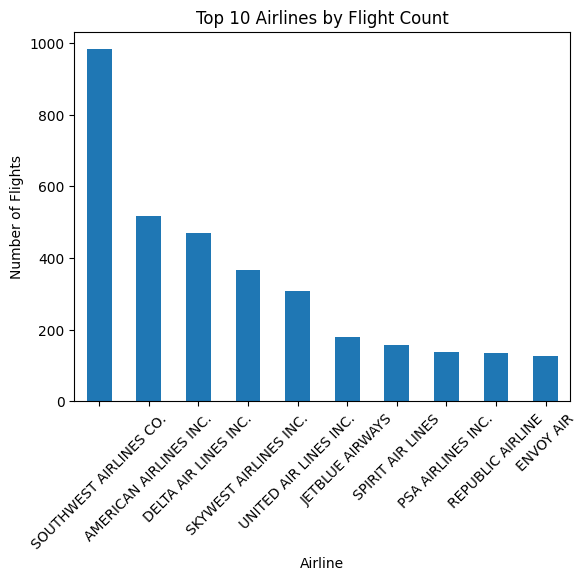

In [ ]:
##Top 10 Airlines by Number of Flights (Bar Chart)
top_airlines = df['AIRLINE'].value_counts().head(10)

plt.figure()
top_airlines.plot(kind='bar')
plt.title("Top 10 Airlines by Flight Count")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

**Top 10 Routes (Origin → Destination)**

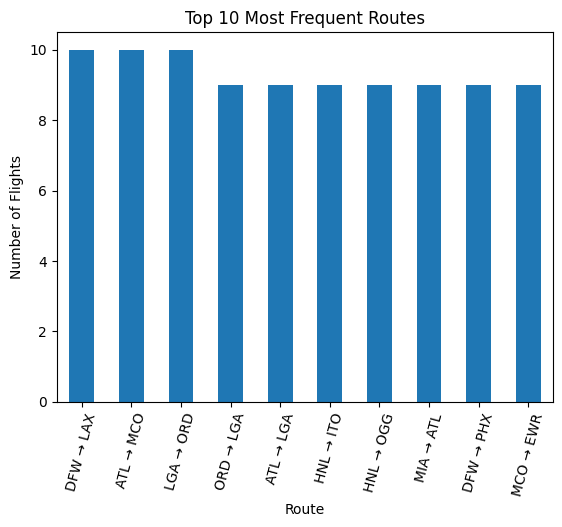

In [ ]:
##Top 10 Routes (Origin → Destination)
df['Route'] = df['ORIGIN'] + " → " + df['DEST']
top_routes = df['Route'].value_counts().head(10)

plt.figure()
top_routes.plot(kind='bar')
plt.title("Top 10 Most Frequent Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.xticks(rotation=75)
plt.show()

**Top Busiest Months (Line Plot)**

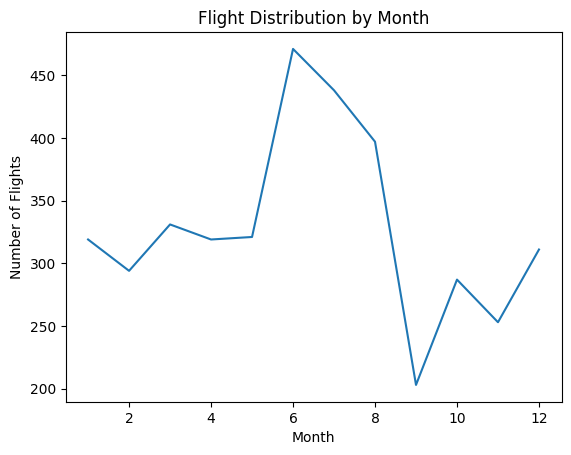

In [ ]:
##Top Busiest Months (Line Plot)
monthly = df['MONTH'].value_counts().sort_index()

plt.figure()
monthly.plot(kind='line')
plt.title("Flight Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

**Flight Distribution by Day of the Week (Bar Chart)**

/tmp/ipykernel_491/711095472.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Day', data=df, order=day_order, palette='magma')


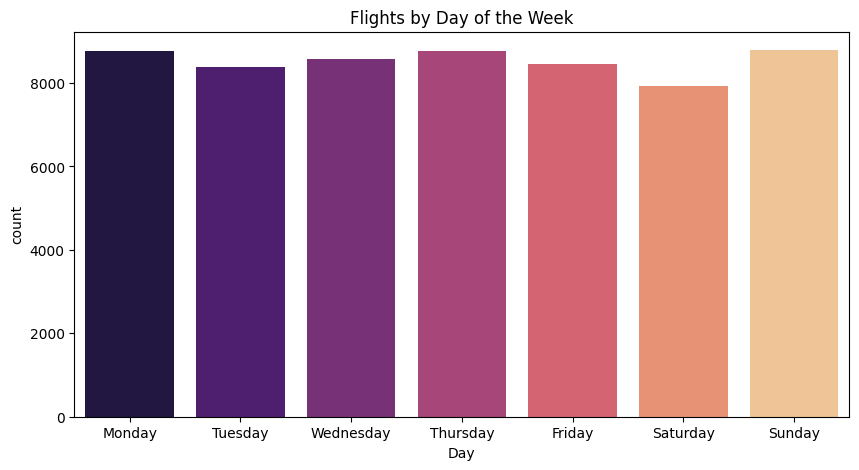

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10,5))
sns.countplot(x='Day', data=df, order=day_order, palette='magma')
plt.title('Flights by Day of the Week')
plt.show()

**Flight Distribution by Month (Line Plot)**

/tmp/ipykernel_491/4133230250.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df, order=month_order, palette='viridis')


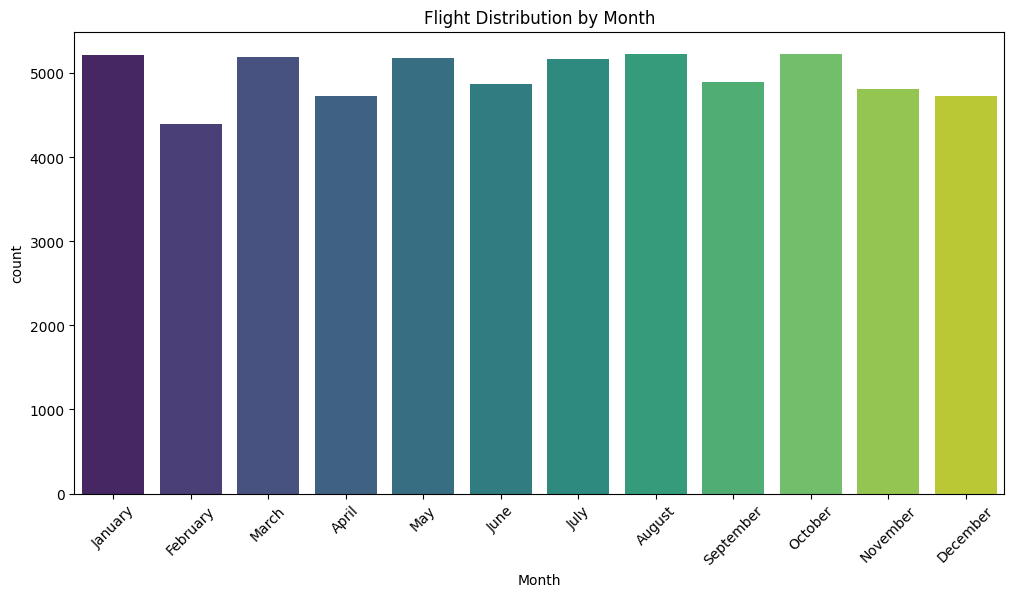

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12,6))
sns.countplot(x='Month', data=df, order=month_order, palette='viridis')
plt.title('Flight Distribution by Month')
plt.xticks(rotation=45)
plt.show()

**Flight Distribution by Time**

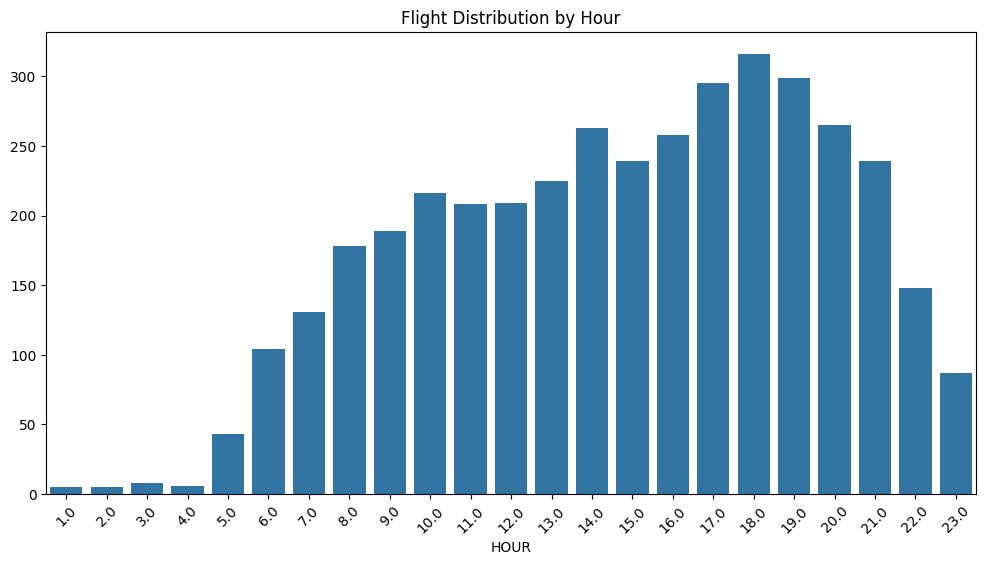

In [ ]:
##Flight Distribution by Time
hour_counts = df['HOUR'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.title("Flight Distribution by Hour")
plt.xticks(rotation=45)
plt.show()

##Week 4 - Delay Analysis
WEEK 4: Delay Analysis – Airline & Weather

**Flight Status Distribution (Pie Chart)**

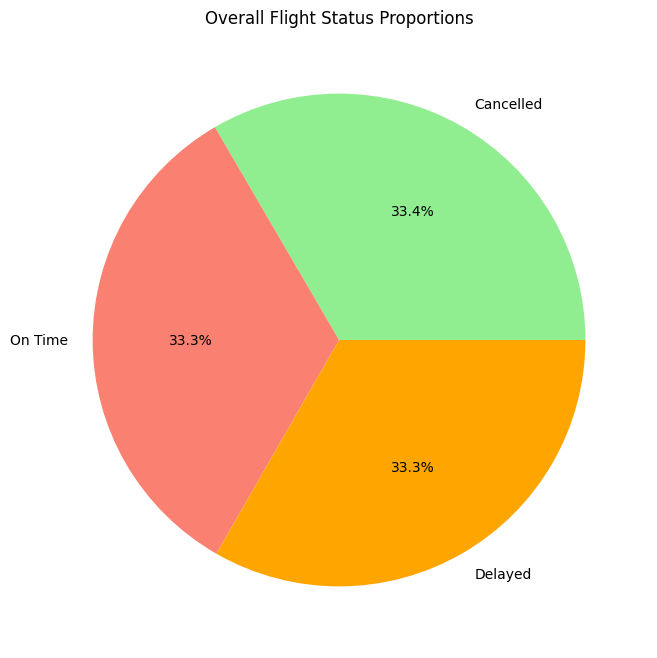

In [ ]:
plt.figure(figsize=(8,8))
df['Flight Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'salmon', 'orange'])
plt.title('Overall Flight Status Proportions')
plt.ylabel('')
plt.show()

**1️.Compare Delay Causes by Airline**

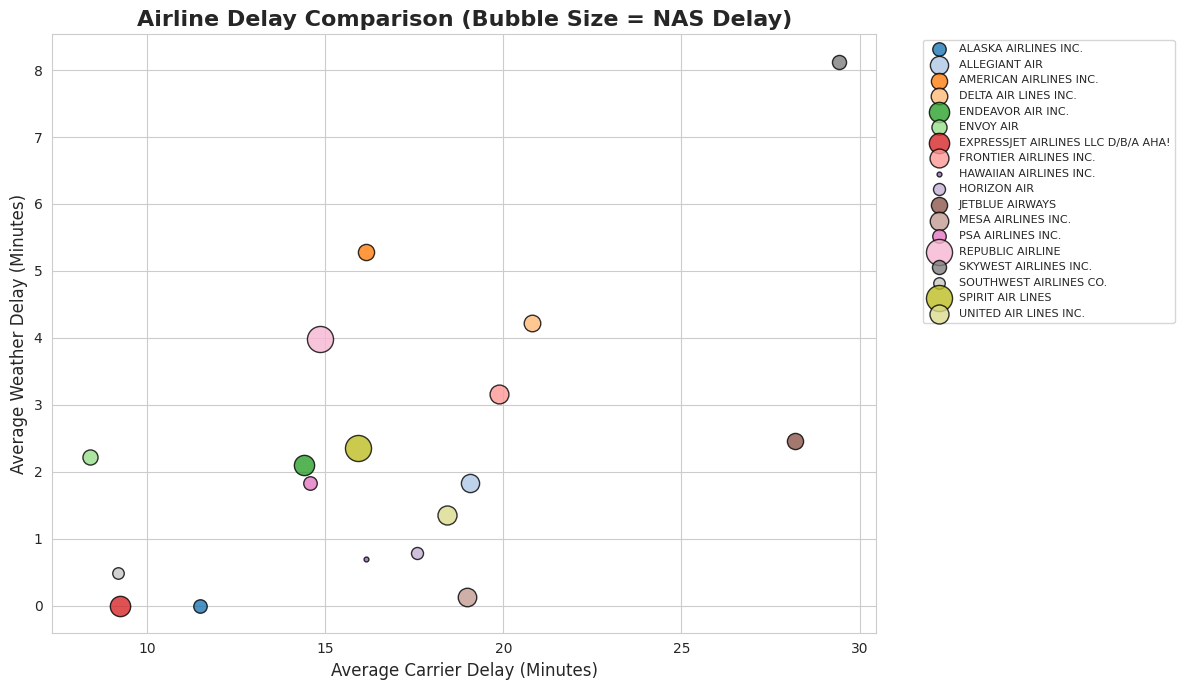

In [36]:
##1.Compare Delay Causes by Airline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Calculate average delay per airline
delay_cols = ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS']
avg_delay = df.groupby('AIRLINE')[delay_cols].mean().reset_index()

# Set professional style
sns.set_style("whitegrid")

plt.figure(figsize=(12,7))

# Generate distinct colors
colors = sns.color_palette("tab20", len(avg_delay))

for i in range(len(avg_delay)):
    plt.scatter(
        avg_delay['DELAY_DUE_CARRIER'][i],
        avg_delay['DELAY_DUE_WEATHER'][i],
        s=avg_delay['DELAY_DUE_NAS'][i] * 20,
        color=colors[i],
        alpha=0.8,
        edgecolors='black',
        linewidth=1,
        label=avg_delay['AIRLINE'][i]
    )

plt.title("Airline Delay Comparison (Bubble Size = NAS Delay)",
          fontsize=16, weight='bold')
plt.xlabel("Average Carrier Delay (Minutes)", fontsize=12)
plt.ylabel("Average Weather Delay (Minutes)", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()



**2.Explore Total Delay Contribution**

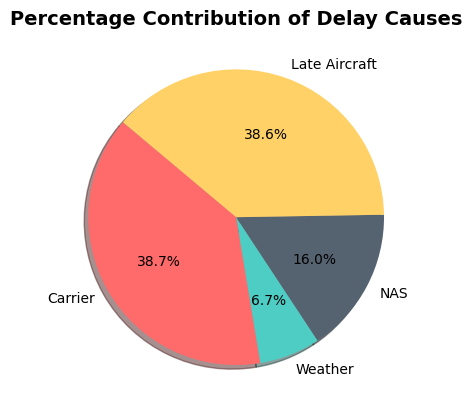

In [6]:
delay_causes_cols = ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_LATE_AIRCRAFT']
total_delay = df[delay_causes_cols].sum()

colors = ['#FF6B6B', '#4ECDC4', '#556270', '#FFD166'] # Added one more color for Late Aircraft
labels = ['Carrier', 'Weather', 'NAS', 'Late Aircraft'] # Added 'Late Aircraft' label

plt.figure()
plt.pie(total_delay,
        labels=labels,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        shadow=True)

plt.title("Percentage Contribution of Delay Causes", fontsize=14, weight='bold')
plt.show()

**3.Visualize Delays by Time of Day (Smooth Line Chart)**

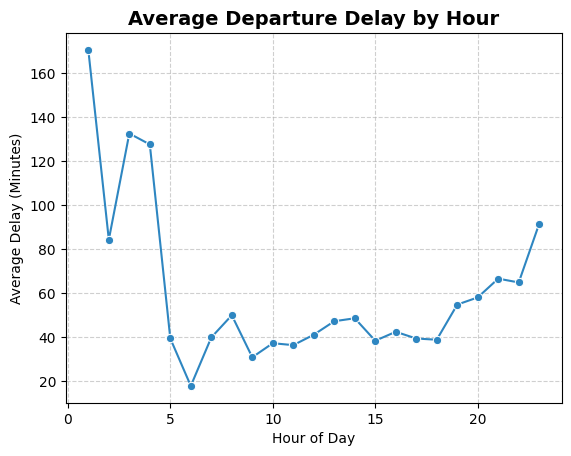

In [9]:
hour_delay = df.groupby('HOUR')['DEP_DELAY'].mean()

plt.figure()
sns.lineplot(x=hour_delay.index,
             y=hour_delay.values,
             marker='o',
             color='#2E86C1')

plt.title("Average Departure Delay by Hour", fontsize=14, weight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (Minutes)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



**4.Arrival Delay Distribution**

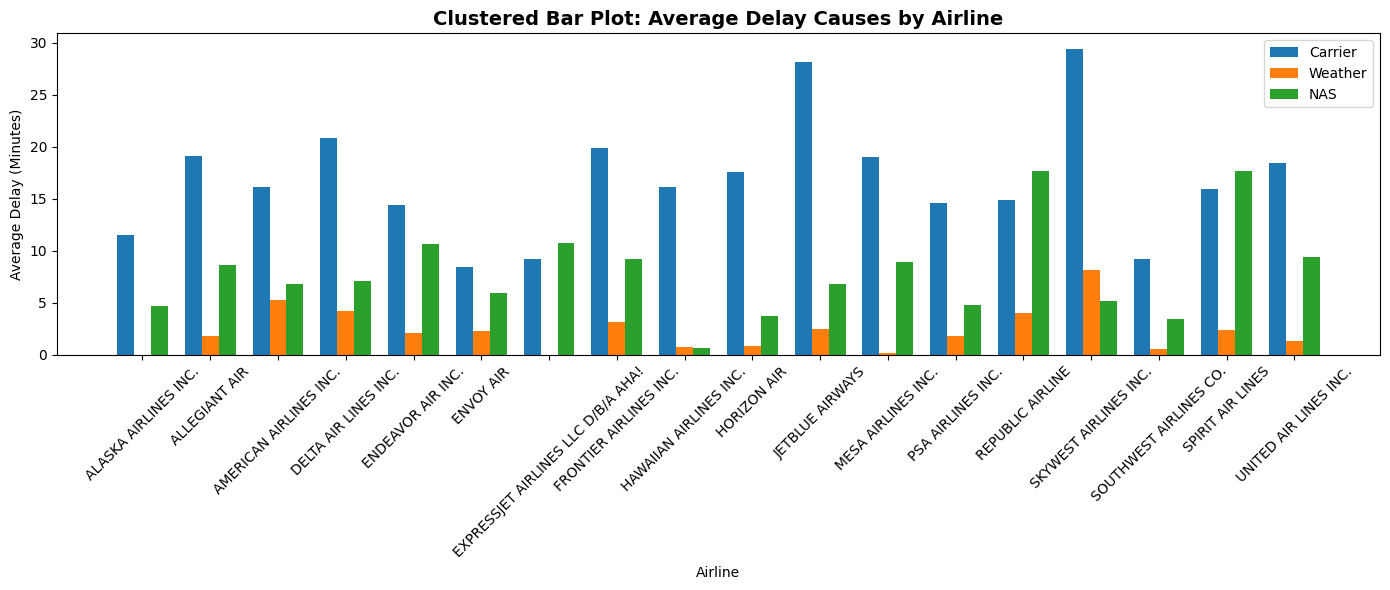

In [24]:
##4.Arrival Delay Distribution
import matplotlib.pyplot as plt
import numpy as np

# Select delay columns
delay_cols = ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS']

# Calculate average delay per airline
avg_delay = df.groupby('AIRLINE')[delay_cols].mean()

# Prepare plot positions
x = np.arange(len(avg_delay.index))
width = 0.25

plt.figure(figsize=(14,6))

plt.bar(x - width, avg_delay['DELAY_DUE_CARRIER'], width, label='Carrier')
plt.bar(x, avg_delay['DELAY_DUE_WEATHER'], width, label='Weather')
plt.bar(x + width, avg_delay['DELAY_DUE_NAS'], width, label='NAS')

plt.xticks(x, avg_delay.index, rotation=45)
plt.title("Clustered Bar Plot: Average Delay Causes by Airline", fontsize=14, weight='bold')
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.legend()
plt.tight_layout()
plt.show()

**3.Visualize Delays by Airport (Top 10 –Bar Chart)**

/tmp/ipykernel_225/3930384527.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airport_delay.index,


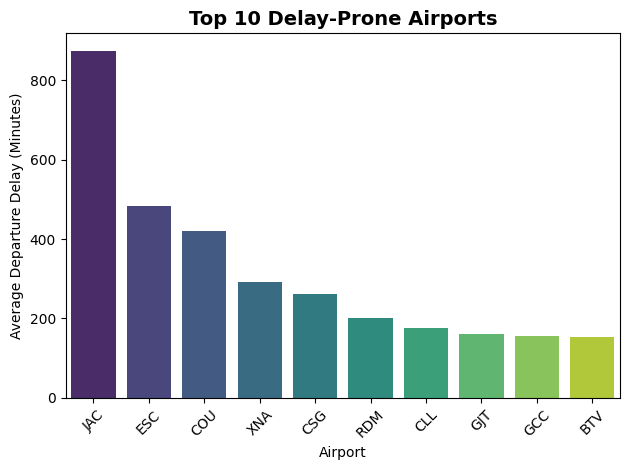

In [10]:
airport_delay = df.groupby('ORIGIN')['DEP_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=airport_delay.index,
            y=airport_delay.values,
            palette='viridis')

plt.xticks(rotation=45)
plt.title("Top 10 Delay-Prone Airports", fontsize=14, weight='bold')
plt.xlabel("Airport")
plt.ylabel("Average Departure Delay (Minutes)")
plt.tight_layout()
plt.show()

##Summaries :-